In [36]:
#Imports

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [37]:
#Load data

import os

path = os.path.abspath('../data/raw/telco_churn_100k.csv')
df = pd.read_csv(path)

In [38]:
# Data cleaning

# Clean Churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Clean Gender (remover valores inválidos)
df = df[df['Gender'].isin(['Male', 'Female'])]

# Reset index
df = df.reset_index(drop=True)

In [39]:
#Feature Engineering

# Avg revenue
df['avg_revenue'] = df['TotalCharges'] / (df['Tenure'] + 1)

# Tenure group
df['tenure_group'] = pd.cut(
    df['Tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12', '12-24', '24-48', '48+']
)

In [40]:
# Enconding 

df_model = df.copy()

categorical_cols = ['Gender', 'Contract', 'PaymentMethod', 'tenure_group']

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

In [41]:
#Features & Target

X = df_model.drop(columns=['CustomerID', 'Churn'])
y = df_model['Churn']

In [42]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# Model (Pipeline) 

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000))])

In [44]:
# Predictions

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [45]:
# Evaluation

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82     12852
           1       0.66      0.53      0.59      6357

    accuracy                           0.75     19209
   macro avg       0.72      0.70      0.71     19209
weighted avg       0.74      0.75      0.75     19209

[[11111  1741]
 [ 3001  3356]]
ROC-AUC: 0.7961471656287007


In [46]:
# Insights

#TN: True Negatives: 11111  → corretos (não churn)
#FP: False Positives: 1741 → falsos alarmes
#FN: False Negatives: 3001 → churn não detetado ⚠️
#TP: True Positives: 3356 → churn detetado


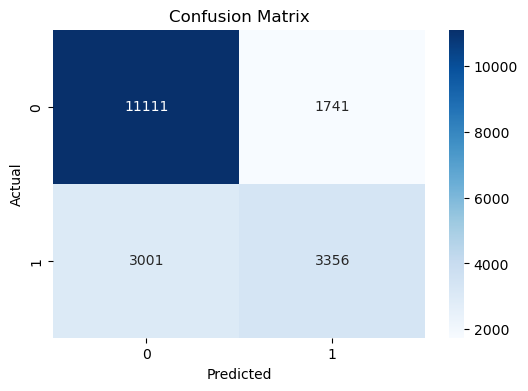

In [47]:
# Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [48]:
# Feature Importance - with pipeline

# Get feature names
feature_names = X.columns

# Get coefficients from model inside pipeline
coefficients = pipeline.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

print(feature_importance.head(10))

                           Feature  Coefficient
2                   MonthlyCharges     0.796721
3                     TotalCharges     0.113428
5                      Gender_Male     0.024386
10      PaymentMethod_Mailed check     0.009627
9   PaymentMethod_Electronic check     0.009102
0                              Age    -0.001930
8        PaymentMethod_Credit card    -0.002093
4                      avg_revenue    -0.164339
1                           Tenure    -0.184073
11              tenure_group_12-24    -0.695089


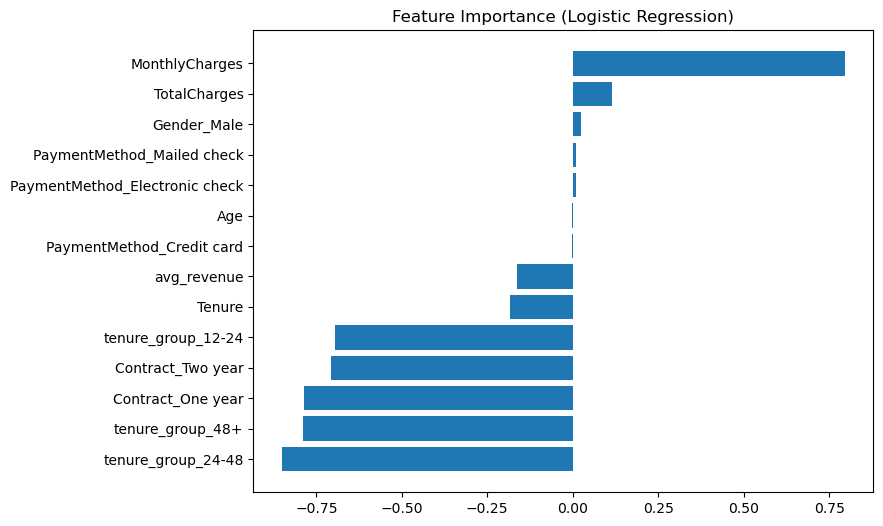

In [49]:
# Feature Visualization

feature_importance_sorted = feature_importance.sort_values(by='Coefficient')

plt.figure(figsize=(8,6))
plt.barh(feature_importance_sorted['Feature'], feature_importance_sorted['Coefficient'])
plt.title('Feature Importance (Logistic Regression)')
plt.show()

In [50]:
# Export to Power BI

# All Data with probabilities
df['churn_probability'] = pipeline.predict_proba(X)[:, 1]

# Risk Category (Creating in Python is safer than in DAX)
def risk_category(row):
    if row['Churn'] == 1:
        return 'Churned'
    elif row['churn_probability'] > 0.7:
        return 'High Risk'
    elif row['churn_probability'] > 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk Category'] = df.apply(risk_category, axis=1)

In [51]:
# Final Export 

df.to_csv('../data/processed/churn_powerbi.csv', index=False)